Prep your data: Have a feature matrix (e.g., from lyrics) and song metadata (title, artist, etc.).

Split into train/validation/test sets (if doing supervised evaluation).

Fit a KNN model on the training set embeddings.

Generate recommendations by querying nearest neighbors.

Evaluate using your validation/test set (if needed).

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors


In [ ]:
df_test_encoded = pd.read_csv('week_5_test_encoded.csv')

df_train_encoded = pd.read_csv('week_5_train_encoded.csv')

df_val_encoded = pd.read_csv('week_5_validation_encoded.csv')

In [ ]:
df_train_encoded.head()

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Loud,Clean_Lyrics,...,Subgenre_rock 90s,Subgenre_rock alternative,Subgenre_soul,Subgenre_soul 60s,Subgenre_soul 70s,Subgenre_soul 80s,Subgenre_soul disco,Subgenre_soul rnb,Tokens,Embeddings
0,Stretch You Out (feat. A Boogie wit da Hoodie),"Summer Walker,A Boogie Wit da Hoodie",0.50,0.317647,0.623529,0.494737,0.252525,0.231579,0.76,get london da track niggas insecure claim enou...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"['get', 'london', 'da', 'track', 'niggas', 'in...",[-5.49920015e-02 -4.24173214e-02 1.20421372e-...
1,On Melancholy Hill,Gorillaz,0.80,0.417647,0.682353,0.726316,0.000000,0.578947,0.80,melancholy hill good side consumerism like muc...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['melancholy', 'hill', 'good', 'side', 'consum...",[-1.40985716e-02 -4.45414186e-02 1.11462869e-...
2,WHO CARES?,Rex Orange County,0.35,0.217647,0.835294,0.242105,0.595960,0.589474,0.80,mmmm mmmm mmmm mmmm first time try free doubt ...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['mmmm', 'mmmm', 'mmmm', 'mmmm', 'first', 'tim...",[-1.85818132e-03 -3.64763662e-02 1.47965446e-...
3,Solid,Ashford & Simpson,0.45,0.305882,0.823529,0.442105,0.272727,0.978947,0.56,love sake mistake oh forgave soon learn trust ...,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"['love', 'sake', 'mistake', 'oh', 'forgave', '...",[-1.36662908e-02 -1.14702322e-02 1.19016811e-...
4,BREAK MY SOUL,Beyoncé,0.55,0.388235,0.682353,0.884211,0.060606,0.863158,0.84,'bout explode take load bend bust open ya make...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[""'bout"", 'explode', 'take', 'load', 'bend', '...",[-5.63979559e-02 -5.03409989e-02 1.03356943e-...


In [ ]:
import numpy as np

def str_to_embedding(s):
    # Remove [ and ] characters
    s = s.strip('[]')
    # Split by spaces and convert each to float
    return np.array([float(x) for x in s.split()])

# Example usage:
embedding_str = "[-5.49920015e-02 -4.24173214e-02 1.20421372e-02]"
embedding_vector = str_to_embedding(embedding_str)
print(embedding_vector)

[-0.054992   -0.04241732  0.01204214]


In [ ]:
df_train_encoded['Embeddings'] = df_train_encoded['Embeddings'].apply(str_to_embedding)


In [ ]:

df_test_encoded['Embeddings'] = df_test_encoded['Embeddings'].apply(str_to_embedding)

df_val_encoded['Embeddings'] = df_val_encoded['Embeddings'].apply(str_to_embedding)


In [ ]:
df_train_encoded.head()

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Loud,Clean_Lyrics,...,Subgenre_rock 90s,Subgenre_rock alternative,Subgenre_soul,Subgenre_soul 60s,Subgenre_soul 70s,Subgenre_soul 80s,Subgenre_soul disco,Subgenre_soul rnb,Tokens,Embeddings
0,Stretch You Out (feat. A Boogie wit da Hoodie),"Summer Walker,A Boogie Wit da Hoodie",0.50,0.317647,0.623529,0.494737,0.252525,0.231579,0.76,get london da track niggas insecure claim enou...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"['get', 'london', 'da', 'track', 'niggas', 'in...","[-0.0549920015, -0.0424173214, 0.120421372, -0..."
1,On Melancholy Hill,Gorillaz,0.80,0.417647,0.682353,0.726316,0.000000,0.578947,0.80,melancholy hill good side consumerism like muc...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['melancholy', 'hill', 'good', 'side', 'consum...","[-0.0140985716, -0.0445414186, 0.111462869, 0...."
2,WHO CARES?,Rex Orange County,0.35,0.217647,0.835294,0.242105,0.595960,0.589474,0.80,mmmm mmmm mmmm mmmm first time try free doubt ...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['mmmm', 'mmmm', 'mmmm', 'mmmm', 'first', 'tim...","[-0.00185818132, -0.0364763662, 0.147965446, 0..."
3,Solid,Ashford & Simpson,0.45,0.305882,0.823529,0.442105,0.272727,0.978947,0.56,love sake mistake oh forgave soon learn trust ...,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"['love', 'sake', 'mistake', 'oh', 'forgave', '...","[-0.0136662908, -0.0114702322, 0.119016811, 0...."
4,BREAK MY SOUL,Beyoncé,0.55,0.388235,0.682353,0.884211,0.060606,0.863158,0.84,'bout explode take load bend bust open ya make...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[""'bout"", 'explode', 'take', 'load', 'bend', '...","[-0.0563979559, -0.0503409989, 0.103356943, -0..."


That should have converted the embeddings to floats instead of a string.

In [ ]:
print(type(df_train_encoded['Embeddings'].iloc[0]))


<class 'numpy.ndarray'>


In order to build a KNN model with just the lyrics we have to convert the embeddings into a matrix.

In [ ]:
X_train = np.stack(df_train_encoded['Embeddings'].values)

X_val = np.stack(df_val_encoded['Embeddings'].values)

X_test = np.stack(df_test_encoded['Embeddings'].values)

Fitting the model using the lyrics in X_train will give the vector space that can be used to generate recommendations.

Starting off with 5 as the number of neighbors, will alter this to tune the model.

###Fitting the KNN model

#### n_neighbours = 5

In [ ]:
knn = NearestNeighbors(n_neighbors=5, metric='cosine')
knn.fit(X_train)

NearestNeighbors(metric='cosine')

Fidning recommendations

In [ ]:
distances, indices = knn.kneighbors(X_test)

### Test 1

In [ ]:
test_song_idx = 0  # first test song
neighbors_indices = indices[test_song_idx]
neighbors_distances = distances[test_song_idx]

print(f"Recommendations for test song: {df_test_encoded['Song'].iloc[test_song_idx]}")
for rank, (idx, dist) in enumerate(zip(neighbors_indices, neighbors_distances), 1):
    song_name = df_train_encoded['Song'].iloc[idx]  # from training set
    print(f"{rank}. {song_name} (distance: {dist:.4f})")


Recommendations for test song: About Damn Time
1. Sativa (distance: 0.0256)
2. Wanna Be Startin' Somethin' (distance: 0.0271)
3. In The Morning (distance: 0.0302)
4. SOS (distance: 0.0306)
5. Smokin Out The Window (distance: 0.0316)


In [ ]:
#Finding song info

df_test_encoded[df_test_encoded['Song'] == "About Damn Time"]


,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Loud,Clean_Lyrics,...,Subgenre_rock 90s,Subgenre_rock alternative,Subgenre_soul,Subgenre_soul 60s,Subgenre_soul 70s,Subgenre_soul 80s,Subgenre_soul disco,Subgenre_soul rnb,Tokens,Embeddings
0,About Damn Time,Lizzo,0.725,0.352941,0.858824,0.726316,0.10101,0.726316,0.8,anyway bad bitch clock yeah thickthirty lot st...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['anyway', 'bad', 'bitch', 'clock', 'yeah', 't...","[-0.0989516005, -0.0316421837, 0.0966719836, -..."


In [ ]:
df_train_encoded[df_train_encoded['Song'] == "In The Morning"]

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Loud,Clean_Lyrics,...,Subgenre_rock 90s,Subgenre_rock alternative,Subgenre_soul,Subgenre_soul 60s,Subgenre_soul 70s,Subgenre_soul 80s,Subgenre_soul disco,Subgenre_soul rnb,Tokens,Embeddings
1296,In The Morning,"J. Cole,Drake",0.6375,0.2,0.388235,0.652632,0.767677,0.473684,0.6,baby summertime fine let get top underline try...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['baby', 'summertime', 'fine', 'let', 'get', '...","[-0.115763538, -0.0358272232, 0.102921471, 0.0..."


In [ ]:
df_train_encoded[df_train_encoded['Song'] == "Wanna Be Startin' Somethin'"]

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Loud,Clean_Lyrics,...,Subgenre_rock 90s,Subgenre_rock alternative,Subgenre_soul,Subgenre_soul 60s,Subgenre_soul 70s,Subgenre_soul 80s,Subgenre_soul disco,Subgenre_soul rnb,Tokens,Embeddings
371,Wanna Be Startin' Somethin',Michael Jackson,0.5875,0.429412,0.858824,0.863158,0.030303,0.926316,0.72,say want startin ' something got startin ' som...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['say', 'want', 'startin', ""'"", 'something', '...","[-0.0842479467, -0.0425135046, 0.0977631807, -..."


In [ ]:
df_train_encoded[df_train_encoded['Song'] == "SOS"]

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Loud,Clean_Lyrics,...,Subgenre_rock 90s,Subgenre_rock alternative,Subgenre_soul,Subgenre_soul 60s,Subgenre_soul 70s,Subgenre_soul 80s,Subgenre_soul disco,Subgenre_soul rnb,Tokens,Embeddings
58,SOS,Rihanna,0.7625,0.517647,0.670588,0.652632,0.000000,0.526316,0.84,lalala lalala lalalalala oh know never feel li...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['lalala', 'lalala', 'lalalalala', 'oh', 'know...","[-0.0948650688, -0.0494057797, 0.117370851, -0..."
1443,SOS,SZA,0.5500,0.411765,0.470588,0.642105,0.676768,0.505263,0.76,last night cry give second give minute nah lil...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['last', 'night', 'cry', 'give', 'second', 'gi...","[-0.0660857782, -0.0262794234, 0.104556039, -0..."
1658,SOS,ABBA,0.6000,0.441176,0.329412,0.705263,0.060606,0.494737,0.84,happy day seem hard find try reach close mind ...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"['happy', 'day', 'seem', 'hard', 'find', 'try'...","[-0.0142980199, -0.088082172, 0.133879215, -0...."


Might have issue with duplicates - Not able to tell? Going to need to include artists along with the song title I think to differentiate

## **Things to try**


*   How to deal with duplicates
*   Different n_neighbour numbers
* Figure out the evaluation portion. Maybe run the kmeans clustering as anothe r"model" and evaluate that for this week




### Test 2 - Same number of neighbours just different song

In [45]:
test_song_idx = 15  # first test song
neighbors_indices = indices[test_song_idx]
neighbors_distances = distances[test_song_idx]

test_song_name = df_test_encoded['Song'].iloc[test_song_idx]
test_artist = df_test_encoded['Artist'].iloc[test_song_idx]

print(f"Recommendations for test song: '{test_song_name}' by '{test_artist}'")

for rank, (idx, dist) in enumerate(zip(neighbors_indices, neighbors_distances), 1):
    song_name = df_train_encoded['Song'].iloc[idx]  # from training set
    artist_name = df_train_encoded['Artist'].iloc[idx]
    print(f"{rank}. '{song_name}' by {artist_name} (distance: {dist:.4f})")


Recommendations for test song: 'Sweet Little Mystery' by 'Wet Wet Wet'
1. 'SOS' by ABBA (distance: 0.0522)
2. 'Should've Been Me' by Mitski (distance: 0.0653)
3. 'The Prince' by Madeon (distance: 0.0679)
4. 'Too Close' by Sir Chloe (distance: 0.0682)
5. 'Miracle Man' by Oliver Tree (distance: 0.0697)


For now asking chat what it would give it similarity wise based on lyrics and semantic meaning

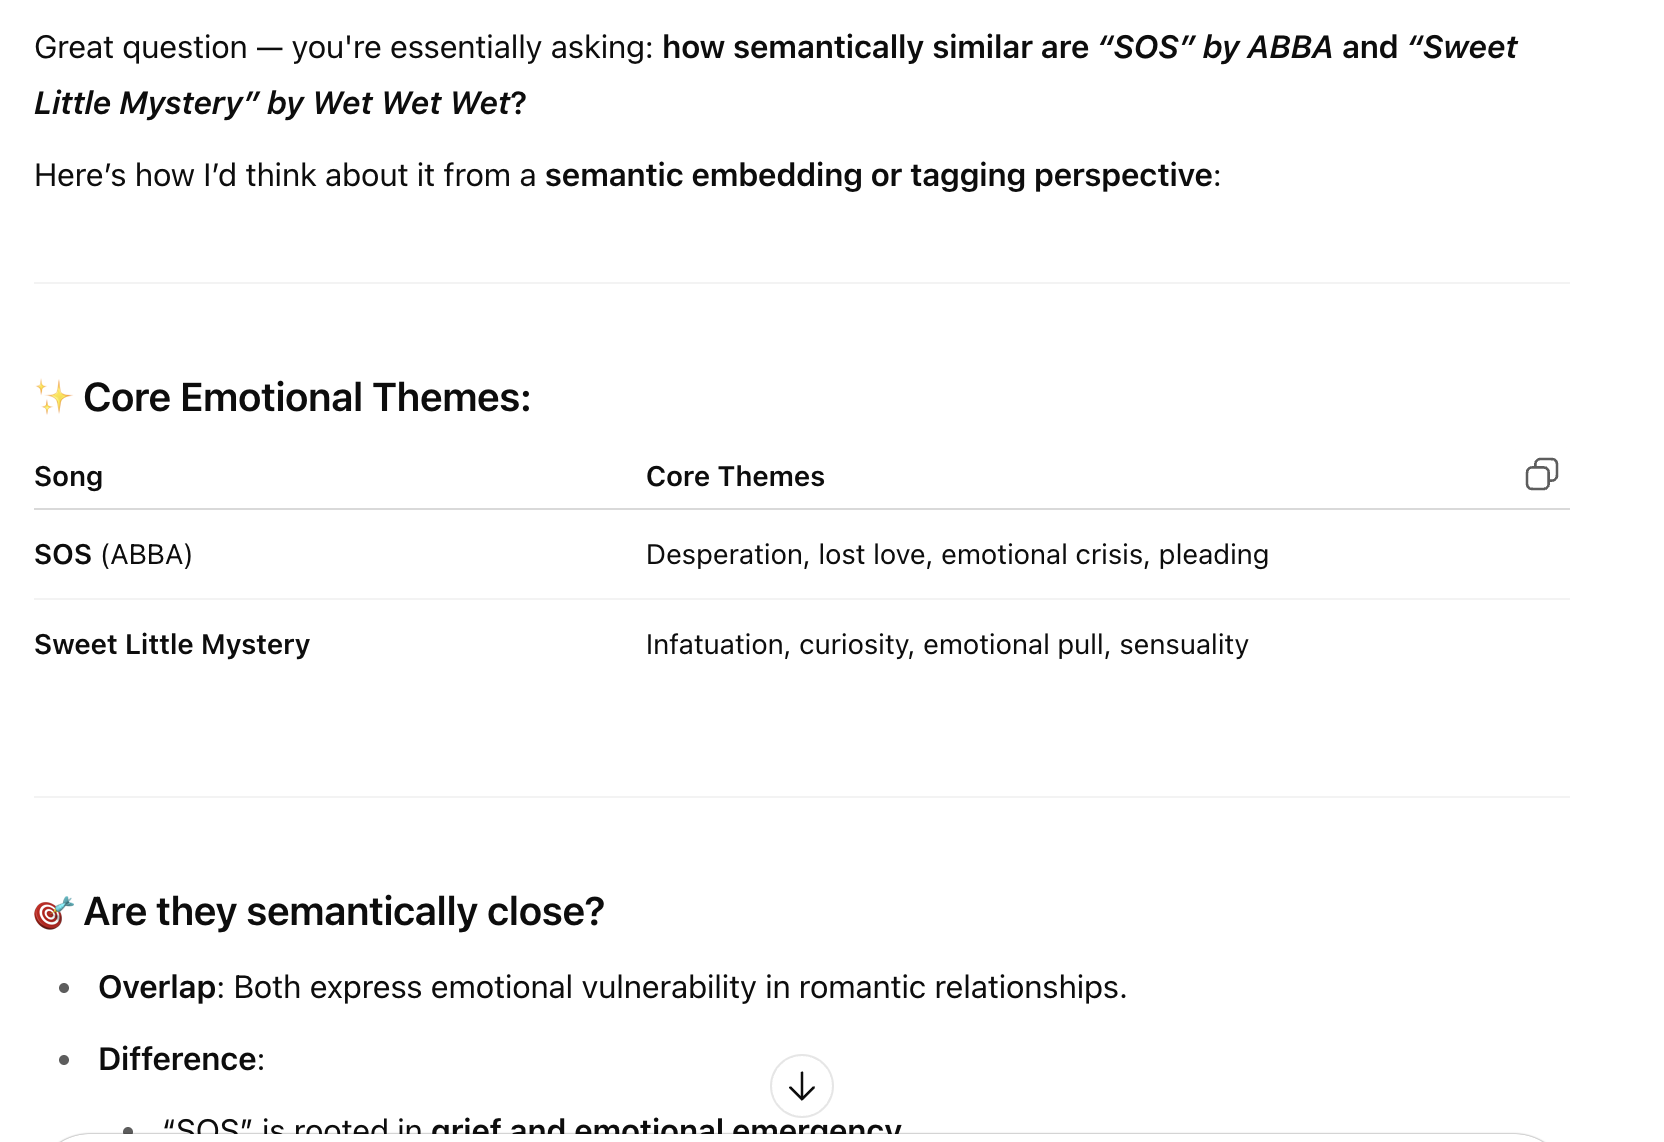

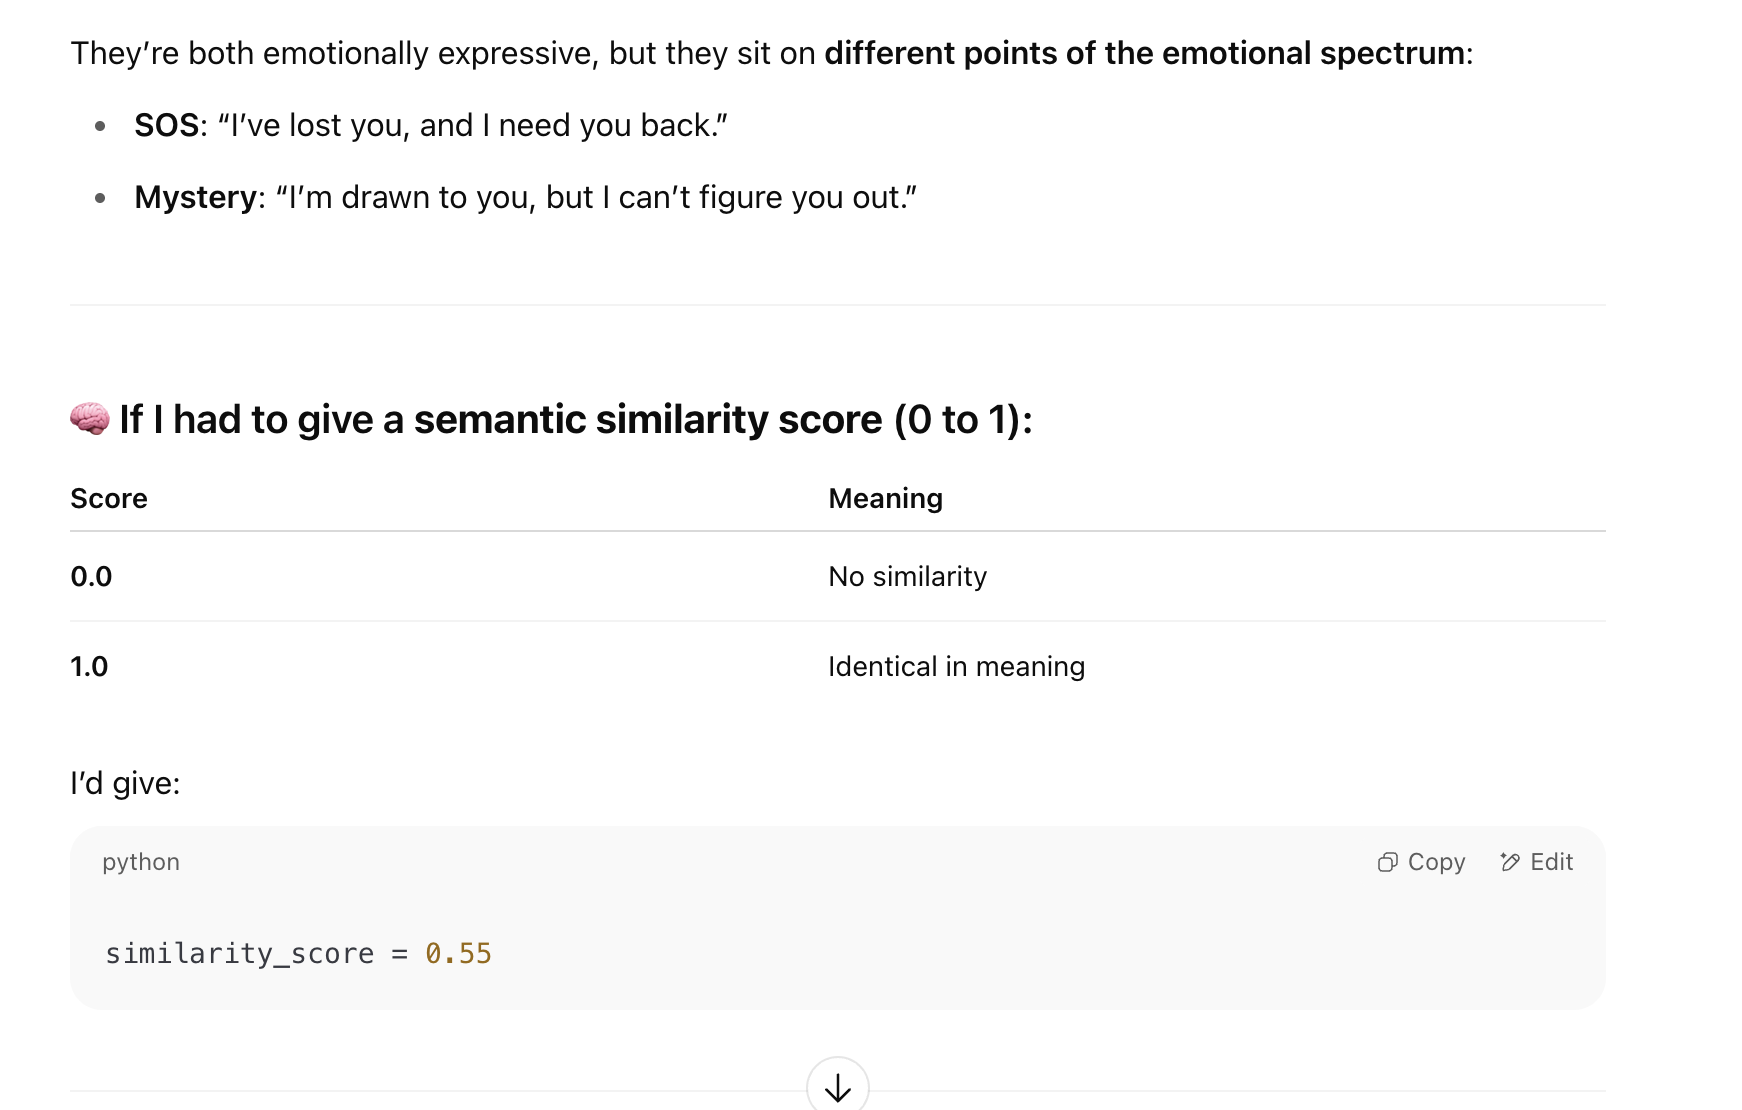

Seeing that lower neighbours = better fitting songs but possibly overfitting (is that a huge issue with our project?)